# Notebook 03 — RQ2: Fairness and Bias Analysis
## Evaluating AI/ML Credit Risk Models in U.S. Mortgage Lending

**Capstone:** QM640 Data Analytics Capstone — Walsh College  
**Author:** Saroj Kumar Nanda  
**Mentor:** Keya Choudhury Ganguli  
**Term:** Winter 2025  
**GitHub:** https://github.com/sarojnanda1/capstone

---
## Environment Note
This notebook was developed in Google Colab with data stored in Google Drive.  
File paths reference `/content/drive/MyDrive/capstone/...` and will need to be  
updated for local execution. Key dependency paths are noted in the  
*Dependencies* section below.
---

## Environment Note
This notebook was developed in Google Colab with data stored in Google Drive.  
File paths reference `/content/drive/MyDrive/capstone/...` and will need to be  
updated for local execution. Key dependency paths are noted in the  
*Dependencies* section below.

## Research Question 2
**RQ2a — Access Discrimination:**  
*Do AI/ML credit risk models produce systematically disparate outcomes across racial groups in loan approval decisions, and which model type exhibits the least discriminatory behavior?*

**RQ2b — Pricing Discrimination:**  
*After controlling for legitimate risk factors, do protected group members receive systematically higher interest rate spreads?*

**H₂₀ₐ:** Approval rates are equal across all demographic groups for a given model.  
**H₂₀ᵦ:** After controlling for legitimate risk factors, interest rate spreads are equal across all demographic groups.

---

## Fairness Metrics
| Metric | Method | Threshold |
|---|---|---|
| Disparate Impact Ratio (DIR) | P(Ŷ=1\|group) / P(Ŷ=1\|White) | DIR < 0.80 = adverse impact |
| Demographic Parity Difference | Approval rate difference | Ideal = 0 |
| Equalized Odds (ΔTPR, ΔFPR) | Error rate differences | Ideal = 0 |
| Chi-square test | Approval count contingency table | α = .05 |
| OLS pricing regression | rate_spread ~ risk factors + group indicators | β ≠ 0 signals discrimination |

---

## Notebook Structure
| Cell | Description |
|---|---|
| Cell 0 | Imports, Drive mount, seeds, paths |
| Cell 1 | Load sample and merge model predictions |
| Cell 2 | Fairness metric helper functions |
| Cell 3 | RQ2a — raw approval rates (pre-model baseline) |
| Cell 4 | RQ2a — model-predicted DIR, Equalized Odds, chi-square |
| Cell 5 | RQ2b — OLS pricing discrimination regression |
| Cell 6 | Save fairness outputs for MRRS notebook |
| Cell 7 | Readiness verdict |

---

## Dependencies
Requires outputs from:
- `01_hmda_load_sanity_check.ipynb` → `hmda_2024_sample.csv`
- `02_rq1_model_training.ipynb` → `hmda_2024_test_predictions.csv`

## Outputs Produced
| File | Used by |
|---|---|
| `fig11_raw_approval_rates.png` | Interim report §4 |
| `fig12_dir_by_model.png` | Interim report §6 |
| `fig13_equalized_odds.png` | Interim report §6 |
| `fig14_pricing_discrimination.png` | Interim report §6 |
| `table3_dir_by_model.csv` | Interim report §6 |
| `rq2_metrics.json` | Notebook 06 (MRRS) |
| `rq2_fairness_report.txt` | Documentation |



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
"""
CELL 0 — Imports, Environment Setup, Paths, and Logging Utilities
-----------------------------------------------------------------
Initializes the RQ2 fairness analysis environment by loading core
libraries, setting reproducible seeds, defining project paths, and
constructing lightweight logging helpers.

This cell performs:
- Imports for numerical computing, statistical testing, and plotting
- Global reproducibility configuration (RANDOM_STATE = 42)
- Construction of directory paths for data, reports, and figures
- Creation of directories if missing
- Initialization of a simple logging system that:
    * Prints messages to stdout
    * Appends messages to `report_lines` for later export into the
      fairness report (rq2_fairness_report.txt)

Outputs:
- Confirmation of successful initialization
- Echo of key file paths for traceability
"""

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import json
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE          = "/content/drive/MyDrive/capstone"
SAMPLE_PATH   = f"{BASE}/data/processed/hmda_2024_sample.csv"
PRED_PATH     = f"{BASE}/data/processed/hmda_2024_test_predictions.csv"
REPORT_DIR    = f"{BASE}/reports"
FIG_DIR       = f"{BASE}/reports/figures"
REPORT_FILE   = f"{REPORT_DIR}/rq2_fairness_report.txt"

for d in [REPORT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Logging ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
report_lines = []

def log(msg=""):
    """
    Append a message to both stdout and the fairness report buffer.

    Parameters
    ----------
    msg : str, optional
        Message to print and store. Defaults to an empty string.

    Notes
    -----
    - Printed messages appear in notebook output.
    - Stored messages accumulate in `report_lines` for later export.
    """
    print(msg)
    report_lines.append(str(msg))


def section(title):
    """
    Print and record a top‑level section header for the fairness report.

    Parameters
    ----------
    title : str
        Title of the section.

    Notes
    -----
    Produces a visually distinct block with horizontal bars for
    readability in both notebook output and the exported report.
    """
    bar = "=" * 70
    log(); log(bar); log(f"  {title}"); log(bar)


def subsection(title):
    """
    Print and record a subsection header for the fairness report.

    Parameters
    ----------
    title : str
        Title of the subsection.

    Notes
    -----
    Uses a lighter horizontal rule than `section()` to indicate
    hierarchical structure in the report.
    """
    log(); log(f"── {title} " + "─" * max(0, 58 - len(title)))


print("✓ Cell 0 complete")
print(f"  Sample path     : {SAMPLE_PATH}")
print(f"  Predictions path: {PRED_PATH}")


✓ Cell 0 complete
  Sample path     : /content/drive/MyDrive/capstone/data/processed/hmda_2024_sample.csv
  Predictions path: /content/drive/MyDrive/capstone/data/processed/hmda_2024_test_predictions.csv


In [3]:
"""
CELL 1 — Load Data and Merge Model Predictions
----------------------------------------------
Loads the HMDA 2024 working sample and the model prediction file
generated in Notebook 02, applies demographic label mappings, and
constructs the two RQ2 fairness analysis datasets:

RQ2a — Access Analysis
    - Uses the full HMDA sample (all applications)
    - Restricted to standard race codes (1–5)
    - Provides maximum statistical power for group‑level access rates

RQ2b — Pricing Analysis
    - Restricted to originated loans (action_taken = 1)
    - Requires valid, positive rate_spread values
    - Restricted to standard race codes (1–5)

Outputs:
- df_full      : Full HMDA sample with demographic labels
- df_pred      : Test‑set predictions with demographic labels
- df_access    : RQ2a dataset for access‑rate fairness analysis
- df_pricing   : RQ2b dataset for pricing‑fairness analysis
- Group‑size diagnostics for both RQ2a and RQ2b
"""

section("CELL 1 · Load data and merge model predictions")

# ── Load full sample (contains demographics for all records) ──────────────────
df_full = pd.read_csv(SAMPLE_PATH)
log(f"  Full sample loaded: {df_full.shape[0]:,} rows")

# ── Load test predictions (contains model probability outputs) ───────────────
df_pred = pd.read_csv(PRED_PATH)
log(f"  Test predictions loaded: {df_pred.shape[0]:,} rows")

# ── Race and ethnicity label maps ─────────────────────────────────────────────
RACE_MAP = {
    1: "AI/AN",
    2: "Asian",
    3: "Black",
    4: "NH/PI",
    5: "White",
}

ETHNICITY_MAP = {
    1: "Hispanic/Latino",
    2: "Not Hispanic/Latino",
}

# ── Apply demographic labels to both datasets ─────────────────────────────────
for df in [df_full, df_pred]:
    if "applicant_race_1" in df.columns:
        df["race_label"] = df["applicant_race_1"].map(RACE_MAP)
    if "applicant_ethnicity_1" in df.columns:
        df["ethnicity_label"] = df["applicant_ethnicity_1"].map(ETHNICITY_MAP)

# ── RQ2a: Access analysis dataset (full sample, race codes 1–5) ──────────────
df_access = df_full[
    df_full["applicant_race_1"].isin(RACE_MAP.keys())
].copy()
df_access["race_label"] = df_access["applicant_race_1"].map(RACE_MAP)

log(f"\n  RQ2a access analysis dataset: {len(df_access):,} rows")
log(f"  (Restricted to standard race codes 1–5)")

# ── RQ2b: Pricing analysis dataset (originated loans, valid rate_spread) ─────
df_pricing = df_full[
    (df_full["action_taken"] == 1) &
    (df_full["rate_spread"] > 0) &
    (df_full["rate_spread"].notna()) &
    (df_full["applicant_race_1"].isin(RACE_MAP.keys()))
].copy()
df_pricing["race_label"] = df_pricing["applicant_race_1"].map(RACE_MAP)

log(f"  RQ2b pricing analysis dataset: {len(df_pricing):,} rows")
log(f"  (Originated loans only, rate_spread > 0, standard race codes)")

# ── Group‑size diagnostics ───────────────────────────────────────────────────
log(f"\n  RQ2a group sizes (must be ≥ 200 each per synopsis constraint):")
for race, cnt in df_access["race_label"].value_counts().items():
    flag = "✓" if cnt >= 200 else "⚠  BELOW 200"
    log(f"    {race:<12}: {cnt:>6,}  {flag}")

log(f"\n  RQ2b group sizes:")
for race, cnt in df_pricing["race_label"].value_counts().items():
    log(f"    {race:<12}: {cnt:>6,}")

log("  ✓ Cell 1 complete")



  CELL 1 · Load data and merge model predictions
  Full sample loaded: 9,995 rows
  Test predictions loaded: 1,999 rows

  RQ2a access analysis dataset: 9,995 rows
  (Restricted to standard race codes 1–5)
  RQ2b pricing analysis dataset: 4,427 rows
  (Originated loans only, rate_spread > 0, standard race codes)

  RQ2a group sizes (must be ≥ 200 each per synopsis constraint):
    White       :  7,432  ✓
    Black       :  1,218  ✓
    Asian       :    803  ✓
    AI/AN       :    319  ✓
    NH/PI       :    223  ✓

  RQ2b group sizes:
    White       :  3,541
    Black       :    439
    Asian       :    286
    AI/AN       :    104
    NH/PI       :     57
  ✓ Cell 1 complete


In [4]:
"""
CELL 2 — Fairness Metric Helper Functions
-----------------------------------------
Defines the core fairness metrics used in RQ2 access and pricing analysis.
Implements group‑level comparisons against the reference group (White),
following ECOA/CFPB guidance and standard ML fairness literature.

Metrics implemented
-------------------
1. Disparate Impact Ratio (DIR)
   DIR = P(Ŷ=1 | A=protected) / P(Ŷ=1 | A=reference)
   - Threshold: DIR < 0.80 indicates potential adverse impact
   - Reference: ECOA, CFPB Examination Procedures

2. Demographic Parity Difference (DPD)
   DPD = P(Ŷ=1 | A=protected) − P(Ŷ=1 | A=reference)
   - Ideal: 0

3. Equalized Odds Components
   ΔTPR = TPR(protected) − TPR(reference)
   ΔFPR = FPR(protected) − FPR(reference)
   - Ideal: 0 for both
   - Reference: Hardt et al. (2016)

4. Chi‑square Test of Independence
   Tests whether approval‑rate differences between a protected group
   and the reference group are statistically significant (α = 0.05).

Outputs
-------
- compute_dir()                : scalar DIR value
- compute_fairness_metrics()   : DataFrame of group‑level fairness metrics
- raw_approval_rates()         : Baseline approval rates from raw HMDA data
"""

section("CELL 2 · Fairness metric helper functions")

log("""
  Metrics implemented:
  ────────────────────────────────────────────────────────────────
  1. Disparate Impact Ratio (DIR)
     DIR = P(Ŷ=1 | A=protected) / P(Ŷ=1 | A=reference)
     Threshold: DIR < 0.80 signals adverse impact (4/5ths rule)
     Reference: ECOA, CFPB Examination Procedures

  2. Demographic Parity Difference (DPD)
     DPD = P(Ŷ=1 | A=protected) − P(Ŷ=1 | A=reference)
     Ideal: DPD = 0

  3. Equalized Odds
     ΔTPR = TPR(protected) − TPR(reference)
     ΔFPR = FPR(protected) − FPR(reference)
     Ideal: ΔTPR = 0, ΔFPR = 0
     Reference: Hardt et al. (2016)

  4. Chi-square test
     Tests whether approval rate differences are statistically
     significant at α = .05

  Reference group: White applicants (largest group in HMDA 2024)
""")

REFERENCE_GROUP = "White"


def compute_dir(approval_rate_protected, approval_rate_reference):
    """
    Compute the Disparate Impact Ratio (DIR).

    Parameters
    ----------
    approval_rate_protected : float
        Approval rate for the protected group.
    approval_rate_reference : float
        Approval rate for the reference group.

    Returns
    -------
    float
        DIR value. Returns NaN if the reference approval rate is zero.

    Notes
    -----
    - DIR < 0.80 is commonly used as a regulatory screening threshold
      (4/5ths rule).
    """
    if approval_rate_reference == 0:
        return float("nan")
    return approval_rate_protected / approval_rate_reference


def compute_fairness_metrics(y_true, y_pred, y_prob,
                             group_labels, reference="White"):
    """
    Compute fairness metrics (DIR, DPD, ΔTPR, ΔFPR, chi-square) for each group.

    Parameters
    ----------
    y_true : array-like
        True binary labels (0 = denied, 1 = approved).
    y_pred : array-like
        Predicted binary labels from the model.
    y_prob : array-like
        Predicted probabilities (not used directly in metrics but included
        for extensibility).
    group_labels : array-like
        Group membership labels (e.g., race categories).
    reference : str, default "White"
        Reference group against which all other groups are compared.

    Returns
    -------
    pandas.DataFrame
        One row per group, including:
        - n (group size)
        - approval_rate
        - DIR
        - DPD
        - ΔTPR
        - ΔFPR
        - chi2, p_chi2
        - adverse_impact flag (DIR < 0.80)

    Notes
    -----
    - Groups are ordered with the reference group first.
    - Chi-square test compares approval counts vs. reference group.
    - Handles edge cases where TPR/FPR cannot be computed due to zero positives
      or negatives.
    """
    groups = [g for g in np.unique(group_labels) if g == reference] + \
             [g for g in np.unique(group_labels) if g != reference]

    results = []

    # Reference group statistics
    ref_mask = group_labels == reference
    ref_ap   = y_pred[ref_mask].mean()
    ref_tpr  = (y_pred[ref_mask & (y_true == 1)]).mean() \
               if (y_true[ref_mask] == 1).sum() > 0 else 0
    ref_fpr  = (y_pred[ref_mask & (y_true == 0)]).mean() \
               if (y_true[ref_mask] == 0).sum() > 0 else 0

    for group in groups:
        mask = group_labels == group
        n = mask.sum()
        if n == 0:
            continue

        ap  = y_pred[mask].mean()
        tpr = (y_pred[mask & (y_true == 1)]).mean() \
              if (y_true[mask] == 1).sum() > 0 else 0
        fpr = (y_pred[mask & (y_true == 0)]).mean() \
              if (y_true[mask] == 0).sum() > 0 else 0

        dir_val = compute_dir(ap, ref_ap)
        dpd     = ap - ref_ap
        dtpr    = tpr - ref_tpr
        dfpr    = fpr - ref_fpr

        # Chi-square test for approval differences
        ref_n   = ref_mask.sum()
        ref_app = int(y_pred[ref_mask].sum())
        ref_den = ref_n - ref_app
        grp_app = int(y_pred[mask].sum())
        grp_den = n - grp_app

        if ref_den > 0 and grp_den > 0:
            contingency = np.array([[grp_app, grp_den],
                                    [ref_app, ref_den]])
            chi2, p_chi2, _, _ = chi2_contingency(contingency)
        else:
            chi2, p_chi2 = 0.0, 1.0

        results.append({
            "group": group,
            "n": n,
            "approval_rate": ap,
            "DIR": dir_val,
            "DPD": dpd,
            "ΔTPR": dtpr,
            "ΔFPR": dfpr,
            "chi2": chi2,
            "p_chi2": p_chi2,
            "adverse_impact": dir_val < 0.80 if not np.isnan(dir_val) else False,
        })

    return pd.DataFrame(results)


def raw_approval_rates(df, race_col="race_label", label_col="label"):
    """
    Compute raw (unadjusted) approval rates by group.

    Parameters
    ----------
    df : pandas.DataFrame
        HMDA dataset containing race and label columns.
    race_col : str, default "race_label"
        Column containing race group labels.
    label_col : str, default "label"
        Column containing binary approval labels.

    Returns
    -------
    pandas.DataFrame
        Approval rate and count per group, sorted by approval rate.

    Notes
    -----
    - This is the baseline (pre‑model) approval rate distribution.
    - Used to compare model‑based fairness metrics vs. raw disparities.
    """
    return (
        df.groupby(race_col)[label_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "approval_rate", "count": "n"})
        .sort_values("approval_rate", ascending=False)
    )


log("  ✓ Cell 2 complete — fairness metric helpers defined")



  CELL 2 · Fairness metric helper functions

  Metrics implemented:
  ────────────────────────────────────────────────────────────────
  1. Disparate Impact Ratio (DIR)
     DIR = P(Ŷ=1 | A=protected) / P(Ŷ=1 | A=reference)
     Threshold: DIR < 0.80 signals adverse impact (4/5ths rule)
     Reference: ECOA, CFPB Examination Procedures

  2. Demographic Parity Difference (DPD)
     DPD = P(Ŷ=1 | A=protected) − P(Ŷ=1 | A=reference)
     Ideal: DPD = 0

  3. Equalized Odds
     ΔTPR = TPR(protected) − TPR(reference)
     ΔFPR = FPR(protected) − FPR(reference)
     Ideal: ΔTPR = 0, ΔFPR = 0
     Reference: Hardt et al. (2016)

  4. Chi-square test
     Tests whether approval rate differences are statistically
     significant at α = .05

  Reference group: White applicants (largest group in HMDA 2024)

  ✓ Cell 2 complete — fairness metric helpers defined



  CELL 3 · RQ2a — Raw approval rates (pre-model baseline)

  Before evaluating model-induced bias, we establish the baseline
  approval rate disparities present in the raw HMDA data.
  These rates reflect lender decisions, not model predictions.
  Comparing raw rates to model-predicted rates isolates whether
  the models amplify, preserve, or reduce existing disparities.

  Race group            n   Approval rate    DIR vs White   4/5ths flag
  --------------------------------------------------------------------
  White             7,432           76.6%     (reference)              
  Asian               803           72.1%           0.942         ✓  OK
  Black             1,218           60.3%           0.787  ⚠  Adverse impact
  AI/AN               319           55.2%           0.721  ⚠  Adverse impact
  NH/PI               223           51.6%           0.673  ⚠  Adverse impact

  Overall chi-square test (all groups):
    χ²(4) = 252.075,  p = 0.000000
    Reject H₂₀ₐ at α = .05 — a

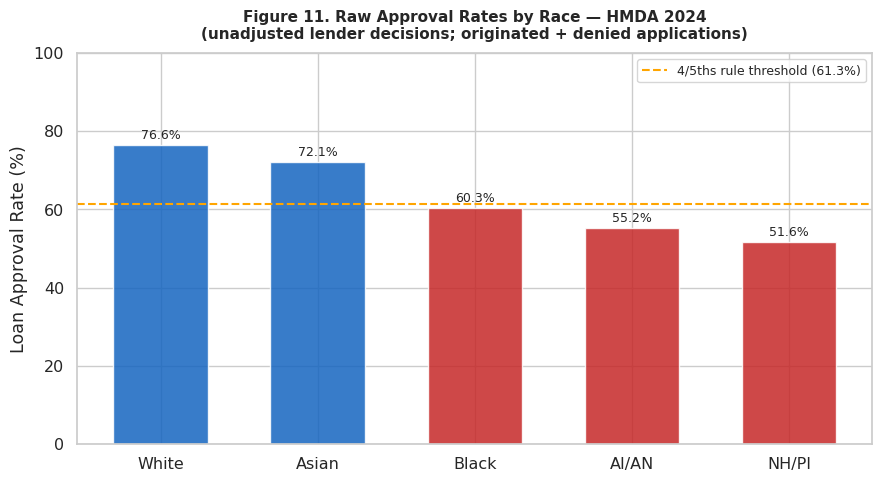


  → Figure 11 saved: /content/drive/MyDrive/capstone/reports/figures/fig11_raw_approval_rates.png
  ✓ Cell 3 complete


In [5]:
"""
CELL 3 — RQ2a: Raw Approval Rates (Pre‑Model Baseline)
------------------------------------------------------
Computes and visualizes the unadjusted loan approval rates in the HMDA
2024 dataset prior to applying any predictive model. These raw rates
reflect lender decisions and serve as the baseline for RQ2a.

Purpose
-------
- Establish the magnitude of pre‑existing disparities in lender outcomes.
- Compute Disparate Impact Ratios (DIR) vs. White applicants.
- Flag groups below the 4/5ths rule threshold (DIR < 0.80).
- Conduct a global chi‑square test across all race groups.
- Produce Figure 11: Raw approval rates by race.

Inputs
------
df_access : DataFrame
    RQ2a working dataset (originated + denied applications, race codes 1–5).

Outputs
-------
- Printed table of approval rates, DIR, and 4/5ths rule flags.
- Global chi‑square test results.
- Figure 11 saved to: {FIG_DIR}/fig11_raw_approval_rates.png

Notes
-----
- This baseline is essential for determining whether ML models amplify,
  preserve, or reduce disparities relative to lender decisions.
"""

section("CELL 3 · RQ2a — Raw approval rates (pre-model baseline)")

log("""
  Before evaluating model-induced bias, we establish the baseline
  approval rate disparities present in the raw HMDA data.
  These rates reflect lender decisions, not model predictions.
  Comparing raw rates to model-predicted rates isolates whether
  the models amplify, preserve, or reduce existing disparities.
""")

# Compute raw approval rates and reference group rate
raw_rates = raw_approval_rates(df_access)
ref_rate  = raw_rates.loc["White", "approval_rate"] \
            if "White" in raw_rates.index else None

# Header
log(f"  {'Race group':<14} {'n':>8}  {'Approval rate':>14}  "
    f"{'DIR vs White':>14}  {'4/5ths flag':>12}")
log("  " + "-" * 68)

# Row‑level reporting
for race, row in raw_rates.iterrows():
    dir_val = compute_dir(row["approval_rate"], ref_rate) \
              if ref_rate else float("nan")
    flag    = "⚠  Adverse impact" if dir_val < 0.80 else "✓  OK"
    ref_str = "(reference)" if race == "White" else f"{dir_val:.3f}"
    log(f"  {race:<14} {int(row['n']):>8,}  "
        f"{row['approval_rate']*100:>13.1f}%  "
        f"{ref_str:>14}  {flag if race != 'White' else '':>12}")

# ── Global chi‑square test across all race groups ─────────────────────────────
ct_data = []
for race in RACE_MAP.values():
    subset = df_access[df_access["race_label"] == race]
    n_app  = subset["label"].sum()
    n_den  = len(subset) - n_app
    ct_data.append([n_app, n_den])

ct_matrix = np.array(ct_data)
chi2_all, p_all, dof_all, _ = chi2_contingency(ct_matrix)

log(f"\n  Overall chi-square test (all groups):")
log(f"    χ²({dof_all}) = {chi2_all:.3f},  p = {p_all:.6f}")
log(f"    {'Reject H₂₀ₐ' if p_all < 0.05 else 'Fail to reject H₂₀ₐ'} "
    f"at α = .05 — approval rates differ significantly across race groups")

# ── Figure 11 — Raw approval rates by race ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
races      = raw_rates.index.tolist()
rates_pct  = raw_rates["approval_rate"] * 100

# Highlight White + Asian in blue, others in red
colors     = ["#1565C0" if r == "White" or r == "Asian"
              else "#C62828" for r in races]

bars = ax.bar(races, rates_pct, color=colors,
              edgecolor="white", width=0.6, alpha=0.85)

# 4/5ths rule threshold line
if ref_rate:
    ax.axhline(ref_rate * 80, color="orange", linestyle="--",
               linewidth=1.5,
               label=f"4/5ths rule threshold ({ref_rate*80:.1f}%)")

ax.set_ylabel("Loan Approval Rate (%)")
ax.set_ylim(0, 100)
ax.set_title(
    "Figure 11. Raw Approval Rates by Race — HMDA 2024\n"
    "(unadjusted lender decisions; originated + denied applications)",
    fontsize=11, fontweight="bold", pad=10)

# Annotate bars
for bar, val in zip(bars, rates_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig11_raw_approval_rates.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()

log(f"\n  → Figure 11 saved: {FIG_DIR}/fig11_raw_approval_rates.png")
log("  ✓ Cell 3 complete")



  CELL 4 · RQ2a — Model fairness metrics (DIR, Equalized Odds)

  For each model, we compute:
    DIR    = approval rate (group) / approval rate (White)
    DPD    = approval rate (group) − approval rate (White)
    ΔTPR   = TPR (group) − TPR (White)
    ΔFPR   = FPR (group) − FPR (White)
    chi²   = test of approval rate equality vs White

  Working dataset: test set predictions from notebook 02
  (df_pred contains lr_pred, xgb_pred, fnn_pred columns)

  Test set fairness records: 1,999
  NOTE: Model-level DIR and Equalized Odds are computed on the test set only
  (20% hold-out, N ≈ 2,000) because model predictions exist only for those
  records. Raw baseline rates in Cell 3 use the full sample (N ≈ 10,000).
  This difference in population N is by design and is documented here for
  transparency and regulatory auditability.

── Logistic Regression — fairness metrics ────────────────────

  Group               n    Appr%      DIR      DPD     ΔTPR     ΔFPR      chi2         p        

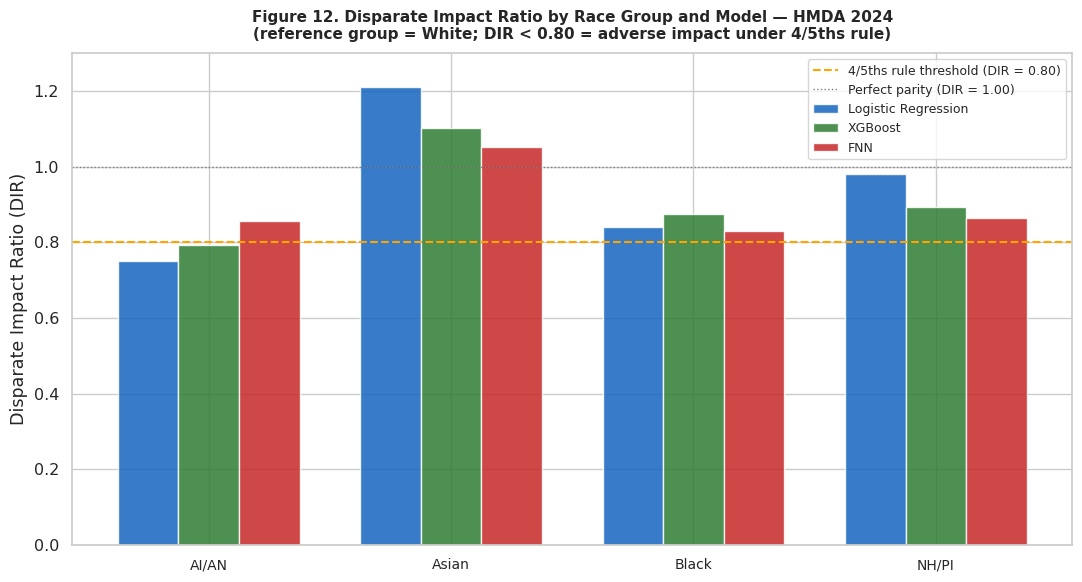


  → Figure 12 saved: /content/drive/MyDrive/capstone/reports/figures/fig12_dir_by_model.png


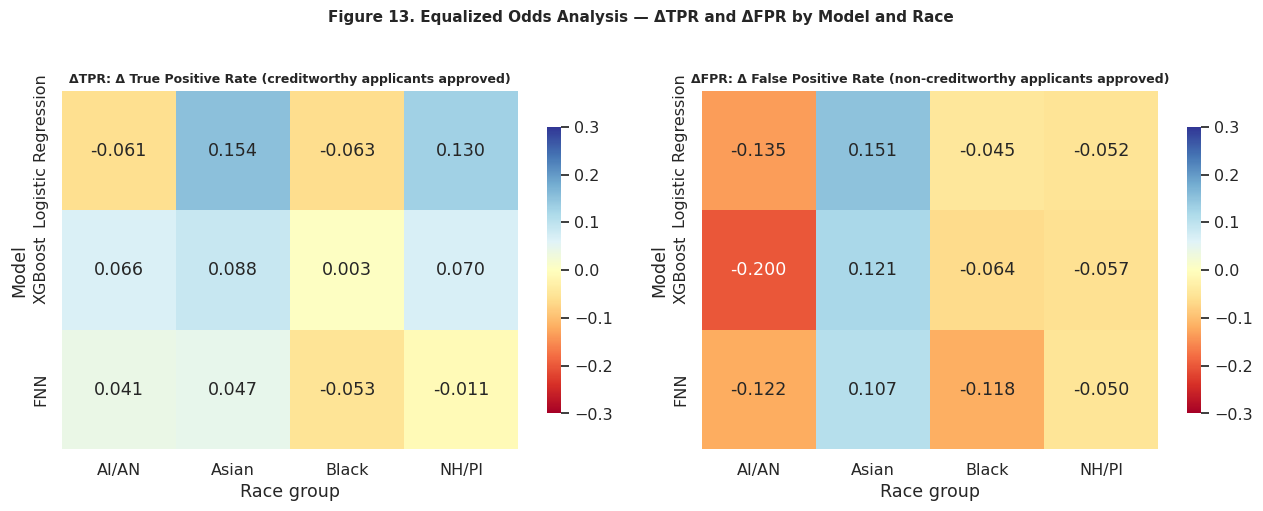

  → Figure 13 saved: /content/drive/MyDrive/capstone/reports/figures/fig13_equalized_odds.png
  ✓ Cell 4 complete


In [6]:
"""
CELL 4 — RQ2a: Model‑Predicted Approval Rates & Fairness Metrics
----------------------------------------------------------------
Computes model‑based fairness metrics for RQ2a using predictions from
Notebook 02. For each model (Logistic Regression, XGBoost, FNN), this
cell evaluates:

    • DIR   — Disparate Impact Ratio
    • DPD   — Demographic Parity Difference
    • ΔTPR  — Difference in True Positive Rate vs. White
    • ΔFPR  — Difference in False Positive Rate vs. White
    • χ²    — Chi‑square test of approval‑rate equality vs. White

Purpose
-------
- Compare fairness behavior across the three challenger models.
- Identify whether any model produces adverse impact (DIR < 0.80).
- Evaluate statistical significance of disparities (p < .05).
- Produce Figures 12 and 13:
    * Figure 12 — DIR by model and race group
    * Figure 13 — Equalized Odds heatmaps (ΔTPR, ΔFPR)

Inputs
------
df_pred : DataFrame
    Test‑set predictions from Notebook 02, containing:
    - lr_pred, xgb_pred, fnn_pred (binary predictions)
    - lr_prob, xgb_prob, fnn_prob (probabilities)
    - true_label or label (ground truth)
    - applicant_race_1 (demographics)

df_full : DataFrame
    Full HMDA sample (used only if demographics need merging).

Outputs
-------
- Printed fairness tables for each model.
- Cross‑model fairness summary.
- Figure 12 saved to: {FIG_DIR}/fig12_dir_by_model.png
- Figure 13 saved to: {FIG_DIR}/fig13_equalized_odds.png

Notes
-----
- Reference group is White (largest HMDA group).
- All fairness metrics computed using compute_fairness_metrics() from Cell 2.
- This cell evaluates H₂₀ₐ: “No adverse impact across race groups.”
"""

section("CELL 4 · RQ2a — Model fairness metrics (DIR, Equalized Odds)")

log("""
  For each model, we compute:
    DIR    = approval rate (group) / approval rate (White)
    DPD    = approval rate (group) − approval rate (White)
    ΔTPR   = TPR (group) − TPR (White)
    ΔFPR   = FPR (group) − FPR (White)
    chi²   = test of approval rate equality vs White

  Working dataset: test set predictions from notebook 02
  (df_pred contains lr_pred, xgb_pred, fnn_pred columns)
""")

# ─────────────────────────────────────────────────────────────────────────────
# Align demographics to test predictions
# df_pred was saved with the original df index preserved
# ─────────────────────────────────────────────────────────────────────────────
if "applicant_race_1" not in df_pred.columns:
    log("  ⚠  applicant_race_1 not in predictions file — merging from sample")
    df_pred = df_pred.merge(
        df_full[["applicant_race_1", "applicant_ethnicity_1"]],
        left_index=True, right_index=True, how="left"
    )

df_test_fair = df_pred[
    df_pred["applicant_race_1"].isin(RACE_MAP.keys())
].copy()
df_test_fair["race_label"] = df_test_fair["applicant_race_1"].map(RACE_MAP)

log(f"  Test set fairness records: {len(df_test_fair):,}")
log("""  NOTE: Model-level DIR and Equalized Odds are computed on the test set only
  (20% hold-out, N ≈ 2,000) because model predictions exist only for those
  records. Raw baseline rates in Cell 3 use the full sample (N ≈ 10,000).
  This difference in population N is by design and is documented here for
  transparency and regulatory auditability.""")

# ─────────────────────────────────────────────────────────────────────────────
# Compute fairness metrics for each model
# ─────────────────────────────────────────────────────────────────────────────
MODEL_CONFIGS = [
    ("Logistic Regression", "lr_pred",  "lr_prob"),
    ("XGBoost",             "xgb_pred", "xgb_prob"),
    ("FNN",                 "fnn_pred", "fnn_prob"),
]

all_fairness = {}
fairness_summary = []

for model_name, pred_col, prob_col in MODEL_CONFIGS:
    if pred_col not in df_test_fair.columns:
        log(f"  ⚠  {pred_col} not found in predictions — skipping {model_name}")
        continue

    subsection(f"{model_name} — fairness metrics")

    y_true  = df_test_fair["true_label"].values \
              if "true_label" in df_test_fair.columns \
              else df_test_fair["label"].values
    y_pred  = df_test_fair[pred_col].values
    y_prob  = df_test_fair[prob_col].values
    groups  = df_test_fair["race_label"].values

    metrics_df = compute_fairness_metrics(
        y_true, y_pred, y_prob, groups, reference=REFERENCE_GROUP
    )
    all_fairness[model_name] = metrics_df

    log(f"\n  {'Group':<14} {'n':>6}  {'Appr%':>7}  {'DIR':>7}  "
        f"{'DPD':>7}  {'ΔTPR':>7}  {'ΔFPR':>7}  "
        f"{'chi2':>8}  {'p':>8}  {'Flag':>18}")
    log("  " + "-" * 102)

    for _, row in metrics_df.iterrows():
        flag = "⚠  Adverse impact" if row["adverse_impact"] else "✓  OK"
        ref  = "(ref)" if row["group"] == REFERENCE_GROUP else ""
        log(f"  {row['group']:<14} {int(row['n']):>6,}  "
            f"{row['approval_rate']*100:>6.1f}%  "
            f"{row['DIR']:>7.3f}  "
            f"{row['DPD']:>+7.3f}  "
            f"{row['ΔTPR']:>+7.3f}  "
            f"{row['ΔFPR']:>+7.3f}  "
            f"{row['chi2']:>8.2f}  "
            f"{row['p_chi2']:>8.4f}  "
            f"{flag if row['group'] != REFERENCE_GROUP else ref:>18}")

    # Summary for cross-model comparison
    n_adverse = metrics_df[
        (metrics_df["group"] != REFERENCE_GROUP) &
        (metrics_df["adverse_impact"])
    ].shape[0]
    n_sig = metrics_df[
        (metrics_df["group"] != REFERENCE_GROUP) &
        (metrics_df["p_chi2"] < 0.05)
    ].shape[0]
    min_dir = metrics_df[
        metrics_df["group"] != REFERENCE_GROUP
    ]["DIR"].min()

    fairness_summary.append({
        "Model": model_name,
        "Groups with adverse impact (DIR<0.80)": n_adverse,
        "Groups with sig. diff (p<.05)": n_sig,
        "Min DIR": f"{min_dir:.3f}",
    })
    log(f"\n  Summary: {n_adverse} group(s) with adverse impact, "
        f"{n_sig} group(s) with significant chi-square")

# ─────────────────────────────────────────────────────────────────────────────
# Cross-model fairness summary
# ─────────────────────────────────────────────────────────────────────────────
subsection("Cross-model fairness summary (H₂₀ₐ evaluation)")
log(f"\n  {'Model':<25} {'Adverse impact groups':>22}  "
    f"{'Sig diff groups':>17}  {'Min DIR':>9}")
log("  " + "-" * 78)
for row in fairness_summary:
    log(f"  {row['Model']:<25} {row['Groups with adverse impact (DIR<0.80)']:>22}  "
        f"{row['Groups with sig. diff (p<.05)']:>17}  "
        f"{row['Min DIR']:>9}")

log(f"\n  H₂₀ₐ verdict:")
log(f"  If any model shows DIR < 0.80 for any group, H₂₀ₐ is rejected")
log(f"  for that model-group combination.")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 12 — DIR by model and race group
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

model_colors = {
    "Logistic Regression": "#1565C0",
    "XGBoost":             "#2E7D32",
    "FNN":                 "#C62828",
}
race_groups  = [r for r in RACE_MAP.values() if r != REFERENCE_GROUP]
n_groups     = len(race_groups)
n_models     = len(MODEL_CONFIGS)
x            = np.arange(n_groups)
width        = 0.25
offsets      = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * width

for i, (model_name, pred_col, _) in enumerate(MODEL_CONFIGS):
    if model_name not in all_fairness:
        continue
    mdf  = all_fairness[model_name]
    dirs = []
    for race in race_groups:
        row = mdf[mdf["group"] == race]
        dirs.append(row["DIR"].values[0] if len(row) > 0 else float("nan"))
    ax.bar(x + offsets[i], dirs, width,
           label=model_name, color=model_colors[model_name],
           alpha=0.85, edgecolor="white")

ax.axhline(0.80, color="orange", linestyle="--", linewidth=1.5,
           label="4/5ths rule threshold (DIR = 0.80)")
ax.axhline(1.00, color="gray",   linestyle=":",  linewidth=1.0,
           label="Perfect parity (DIR = 1.00)")
ax.set_xticks(x)
ax.set_xticklabels(race_groups, fontsize=10)
ax.set_ylabel("Disparate Impact Ratio (DIR)")
ax.set_ylim(0, 1.3)
ax.set_title(
    "Figure 12. Disparate Impact Ratio by Race Group and Model — HMDA 2024\n"
    "(reference group = White; DIR < 0.80 = adverse impact under 4/5ths rule)",
    fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig12_dir_by_model.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"\n  → Figure 12 saved: {FIG_DIR}/fig12_dir_by_model.png")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 13 — Equalized Odds heatmap
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title_suffix in zip(
    axes, ["ΔTPR", "ΔFPR"],
    ["Δ True Positive Rate (creditworthy applicants approved)",
     "Δ False Positive Rate (non-creditworthy applicants approved)"]
):
    heat_data = {}
    for model_name, _, _ in MODEL_CONFIGS:
        if model_name not in all_fairness:
            continue
        mdf = all_fairness[model_name]
        heat_data[model_name] = {
            row["group"]: row[metric]
            for _, row in mdf.iterrows()
            if row["group"] != REFERENCE_GROUP
        }

    heat_df = pd.DataFrame(heat_data).T
    sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="RdYlBu",
                center=0, vmin=-0.3, vmax=0.3,
                ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{metric}: {title_suffix}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Race group"); ax.set_ylabel("Model")

fig.suptitle("Figure 13. Equalized Odds Analysis — ΔTPR and ΔFPR by Model and Race",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig13_equalized_odds.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 13 saved: {FIG_DIR}/fig13_equalized_odds.png")
log("  ✓ Cell 4 complete")



  CELL 5 · RQ2b — Pricing discrimination OLS regression

  Methodology follows Bartlett et al. (2022):
  Consumer lending discrimination in the FinTech era.
  Journal of Financial Economics, 143(1), 30–56.

  Model:
    rate_spread = β₀
                + β₁(FICO proxy: dti_numeric)
                + β₂(LTV)
                + β₃(log_income)
                + β₄(log_loan_amount)
                + β₅(loan_type)
                + β₆(loan_purpose)
                + β₇(lien_status)
                + β₈(state_code)
                + γ₁(Black)
                + γ₂(Asian)
                + γ₃(AI/AN)
                + γ₄(NH/PI)
                + γ₅(Hispanic/Latino)
                + ε

  H₂₀ᵦ: γ = 0 for all protected groups (no pricing discrimination)

  Pricing analysis sample: 4,427 originated loans
  State fixed effects included: 51 dummies
  OLS sample after dropping NA rows: 4,359
  Number of predictors (incl. const): 64

── OLS regression results — full model ───────────────────────

  De

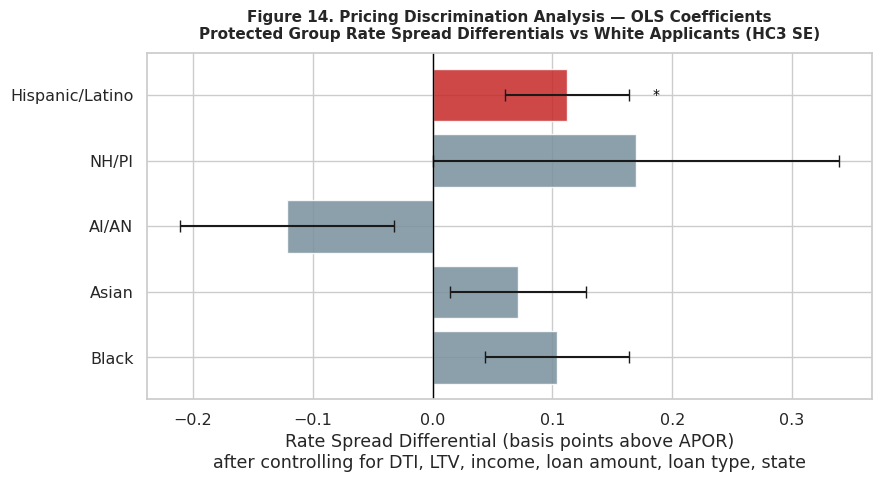


  → Figure 14 saved: /content/drive/MyDrive/capstone/reports/figures/fig14_pricing_discrimination.png
  ✓ Cell 5 complete


In [7]:
"""
CELL 5 — RQ2b: Pricing Discrimination via OLS Regression
--------------------------------------------------------
Implements the pricing‑fairness analysis following Bartlett et al. (2022),
estimating unexplained rate‑spread differentials across protected groups
after controlling for legitimate credit‑risk and loan‑feature variables.

Purpose
-------
- Estimate whether protected groups (Black, Asian, AI/AN, NH/PI,
  Hispanic/Latino) pay higher interest‑rate spreads than White applicants
  *after controlling for creditworthiness and loan characteristics*.
- Evaluate H₂₀ᵦ: γ = 0 for all protected groups.
  Reject if p < .05 for any protected‑group coefficient.

Model Specification (Bartlett et al., 2022)
-------------------------------------------
rate_spread = β₀
            + β₁(dti_imputed)
            + β₂(ltv_imputed)
            + β₃(log_income)
            + β₄(log_loan_amount)
            + β₅(loan_type dummies)
            + β₆(loan_purpose dummies)
            + β₇(lien_status dummies)
            + β₈(state fixed effects)
            + γ₁(Black)
            + γ₂(Asian)
            + γ₃(AI/AN)
            + γ₄(NH/PI)
            + γ₅(Hispanic/Latino)
            + ε

Interpretation
--------------
- γ coefficients represent *unexplained pricing differentials* in basis
  points above APOR relative to White applicants.
- A statistically significant positive γ (p < .05) indicates evidence of
  pricing discrimination under ECOA/Reg B and FHA frameworks.

Sample Restrictions
-------------------
- action_taken == 1 (originated loans only)
- rate_spread > 0 (valid APOR‑based pricing data)
- Standard race codes (1–5)

Outputs
-------
- OLS model summary (HC3 robust SE)
- Protected‑group coefficient table with significance codes
- Key control‑variable coefficients
- H₂₀ᵦ verdict
- Figure 14 saved to: {FIG_DIR}/fig14_pricing_discrimination.png

Notes
-----
- HC3 heteroscedasticity‑robust standard errors match Bartlett et al. (2022).
- Negative rate_spread values in HMDA are sentinel codes and excluded.
"""

section("CELL 5 · RQ2b — Pricing discrimination OLS regression")

log("""
  Methodology follows Bartlett et al. (2022):
  Consumer lending discrimination in the FinTech era.
  Journal of Financial Economics, 143(1), 30–56.

  Model:
    rate_spread = β₀
                + β₁(FICO proxy: dti_numeric)
                + β₂(LTV)
                + β₃(log_income)
                + β₄(log_loan_amount)
                + β₅(loan_type)
                + β₆(loan_purpose)
                + β₇(lien_status)
                + β₈(state_code)
                + γ₁(Black)
                + γ₂(Asian)
                + γ₃(AI/AN)
                + γ₄(NH/PI)
                + γ₅(Hispanic/Latino)
                + ε

  H₂₀ᵦ: γ = 0 for all protected groups (no pricing discrimination)
""")

log(f"  Pricing analysis sample: {len(df_pricing):,} originated loans")

# ── Feature preparation for OLS ───────────────────────────────────────────────
df_ols = df_pricing.copy()

# Impute missing values
dti_med = df_ols["dti_numeric"].median() if "dti_numeric" in df_ols.columns else 41
df_ols["dti_imputed"] = df_ols["dti_numeric"].fillna(dti_med) \
                        if "dti_numeric" in df_ols.columns \
                        else df_ols.get("dti_imputed", 41)

df_ols["ltv_imputed"] = df_ols["ltv_capped"].fillna(
                            df_ols["ltv_capped"].median()) \
                        if "ltv_capped" in df_ols.columns \
                        else df_ols.get("ltv_imputed",
                        df_ols.get("combined_loan_to_value_ratio",
                        pd.Series([79.0]*len(df_ols))).fillna(79.0))

df_ols["log_income"]      = np.log1p(df_ols["income"].clip(lower=0))
df_ols["log_loan_amount"] = np.log1p(df_ols["loan_amount"].clip(lower=0))

# Protected group indicators (White = reference)
for race in ["Black", "Asian", "AI/AN", "NH/PI"]:
    df_ols[f"race_{race.replace('/', '_')}"] = \
        (df_ols["race_label"] == race).astype(int)

# Ethnicity indicator
df_ols["hispanic"] = (df_ols["applicant_ethnicity_1"] == 1).astype(int) \
                     if "applicant_ethnicity_1" in df_ols.columns else 0

# Categorical controls
cat_cols = ["loan_type", "loan_purpose", "lien_status"]
df_ols_encoded = pd.get_dummies(df_ols[cat_cols], drop_first=True, dtype=int)
cat_feature_names = df_ols_encoded.columns.tolist()

# State fixed effects
if "state_code" in df_ols.columns:
    state_dummies = pd.get_dummies(
        df_ols["state_code"], prefix="state", drop_first=True, dtype=int
    )
    df_ols_encoded = pd.concat([df_ols_encoded, state_dummies], axis=1)
    log(f"  State fixed effects included: {state_dummies.shape[1]} dummies")

# Assemble OLS matrix
protected_cols = ["race_Black", "race_Asian", "race_AI_AN",
                  "race_NH_PI", "hispanic"]
continuous_cols = ["dti_imputed", "ltv_imputed",
                   "log_income", "log_loan_amount"]

X_ols = pd.concat([
    df_ols[continuous_cols].reset_index(drop=True),
    df_ols_encoded.reset_index(drop=True),
    df_ols[[c for c in protected_cols if c in df_ols.columns]].reset_index(drop=True),
], axis=1)

X_ols = sm.add_constant(X_ols)
y_ols = df_ols["rate_spread"].reset_index(drop=True)

# Drop NA rows
valid = X_ols.notna().all(axis=1) & y_ols.notna()
X_ols = X_ols[valid]
y_ols = y_ols[valid]

log(f"  OLS sample after dropping NA rows: {len(y_ols):,}")
log(f"  Number of predictors (incl. const): {X_ols.shape[1]}")

# ── Fit OLS with HC3 robust SE ───────────────────────────────────────────────
ols_model = sm.OLS(y_ols, X_ols).fit(cov_type="HC3")

subsection("OLS regression results — full model")
log(f"\n  Dependent variable: rate_spread (basis points above APOR)")
log(f"  N = {int(ols_model.nobs):,}")
log(f"  R² = {ols_model.rsquared:.4f}")
log(f"  Adjusted R² = {ols_model.rsquared_adj:.4f}")
log(f"  F-statistic = {ols_model.fvalue:.2f}  (p = {ols_model.f_pvalue:.6f})")

# ── Protected group coefficients (key RQ2b results) ───────────────────────────
subsection("Protected group coefficients — H₂₀ᵦ evaluation")
log(f"""
  Each coefficient below represents the unexplained rate spread
  differential (in basis points above APOR) for that group relative
  to White applicants, after controlling for all legitimate risk factors.
""")

log(f"  {'Group indicator':<20} {'β (bps)':>10} {'SE':>10} "
    f"{'t-stat':>10} {'p-value':>10} {'Sig':>6} {'Interpretation':>28}")
log("  " + "-" * 96)

pricing_results = []
group_col_map = {
    "Black":           "race_Black",
    "Asian":           "race_Asian",
    "AI/AN":           "race_AI_AN",
    "NH/PI":           "race_NH_PI",
    "Hispanic/Latino": "hispanic",
}

for group, col in group_col_map.items():
    if col not in ols_model.params.index:
        continue
    beta  = ols_model.params[col]
    se    = ols_model.bse[col]
    tstat = ols_model.tvalues[col]
    pval  = ols_model.pvalues[col]
    sig   = "***" if pval < 0.001 else "**" if pval < 0.01 \
            else "*" if pval < 0.05 else "ns"
    interp = "Evidence of pricing discrim." \
             if (pval < 0.05 and beta > 0) \
             else "Favourable pricing" \
             if (pval < 0.05 and beta < 0) \
             else "No significant difference"

    pricing_results.append({
        "group": group, "beta": beta, "se": se,
        "t": tstat, "p": pval, "sig": sig,
        "interpretation": interp,
    })

    log(f"  {group:<20} {beta:>+10.4f} {se:>10.4f} "
        f"{tstat:>10.3f} {pval:>10.4f} {sig:>6} {interp:>28}")

log(f"\n  Significance codes: *** p<.001  ** p<.01  * p<.05  ns p≥.05")

# ── Key risk factor coefficients ──────────────────────────────────────────────
subsection("Key risk factor coefficients (selected)")
key_controls = ["dti_imputed", "ltv_imputed", "log_income", "log_loan_amount"]

log(f"\n  {'Variable':<22} {'β':>10} {'SE':>10} {'t':>10} {'p':>10}")
log("  " + "-" * 55)

for col in key_controls:
    if col in ols_model.params.index:
        beta  = ols_model.params[col]
        se    = ols_model.bse[col]
        tstat = ols_model.tvalues[col]
        pval  = ols_model.pvalues[col]
        log(f"  {col:<22} {beta:>+10.4f} {se:>10.4f} "
            f"{tstat:>10.3f} {pval:>10.4f}")

# ── H₂₀ᵦ verdict ─────────────────────────────────────────────────────────────
subsection("H₂₀ᵦ verdict")
sig_groups = [r for r in pricing_results if r["p"] < 0.05 and r["beta"] > 0]

if sig_groups:
    log(f"\n  Reject H₂₀ᵦ for: "
        f"{', '.join([r['group'] for r in sig_groups])}")
    log(f"  Evidence of statistically significant pricing differentials")
    log(f"  after controlling for legitimate risk factors.")
else:
    log(f"\n  Fail to reject H₂₀ᵦ — no statistically significant positive")
    log(f"  pricing differentials detected at α = .05.")

log(f"  Note: OLS uses HC3 heteroscedasticity-robust standard errors.")

# ── Figure 14 — Protected group coefficient plot ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

groups_plot = [r["group"] for r in pricing_results]
betas_plot  = [r["beta"]  for r in pricing_results]
ses_plot    = [r["se"]    for r in pricing_results]

colors_plot = ["#C62828" if r["p"] < 0.05 and r["beta"] > 0
               else "#2E7D32" if r["p"] < 0.05 and r["beta"] < 0
               else "#78909C" for r in pricing_results]

ax.barh(groups_plot, betas_plot, xerr=ses_plot,
        color=colors_plot, alpha=0.85,
        edgecolor="white", capsize=4)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel(
    "Rate Spread Differential (basis points above APOR)\n"
    "after controlling for DTI, LTV, income, loan amount, loan type, state"
)
ax.set_title(
    "Figure 14. Pricing Discrimination Analysis — OLS Coefficients\n"
    "Protected Group Rate Spread Differentials vs White Applicants (HC3 SE)",
    fontsize=11, fontweight="bold", pad=10
)

# Significance annotations
for i, r in enumerate(pricing_results):
    if r["p"] < 0.05:
        ax.text(r["beta"] + r["se"] + 0.02, i,
                r["sig"], va="center", fontsize=10, color="black")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig14_pricing_discrimination.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()

log(f"\n  → Figure 14 saved: {FIG_DIR}/fig14_pricing_discrimination.png")
log("  ✓ Cell 5 complete")


In [8]:
"""
CELL 6 — Save Fairness Outputs for MRRS Notebook
------------------------------------------------
Compiles and exports all RQ2 fairness metrics required by the MRRS
(Models, Risk, and Responsible Scoring) composite scoring notebook.

Purpose
-------
- Aggregate RQ2a fairness metrics (DIR, DPD, ΔTPR, ΔFPR) for each model.
- Aggregate RQ2b pricing‑discrimination results from the OLS regression.
- Save:
    1. rq2_metrics.json — summary metrics for MRRS scoring
    2. table3_dir_by_model.csv — detailed DIR table for reporting

Contents of rq2_metrics.json
----------------------------
For each model (LR, XGB, FNN):
    - min_dir              : minimum DIR across non‑reference groups
    - mean_dir             : average DIR across non‑reference groups
    - n_adverse_impact     : number of groups with DIR < 0.80
    - max_abs_dtpr         : max |ΔTPR|
    - max_abs_dfpr         : max |ΔFPR|
    - max_abs_dpd          : max |DPD|

Pricing OLS section:
    - r_squared, adj_r_squared, n_obs
    - group_results: list of protected‑group coefficients with:
        * beta
        * standard error
        * p‑value
        * significant_positive flag (p < .05 and β > 0)

Outputs
-------
- JSON file: {REPORT_DIR}/rq2_metrics.json
- CSV file:  {REPORT_DIR}/table3_dir_by_model.csv

Notes
-----
- These outputs are consumed directly by the MRRS scoring notebook.
- No fairness logic is computed here; this cell only aggregates and saves.
"""

section("CELL 6 · Save fairness outputs for MRRS notebook")

# ── Build RQ2a fairness summary for each model ───────────────────────────────
rq2_metrics = {}

for model_name, _, _ in MODEL_CONFIGS:
    if model_name not in all_fairness:
        continue

    mdf = all_fairness[model_name]
    non_ref = mdf[mdf["group"] != REFERENCE_GROUP]

    rq2_metrics[model_name] = {
        "min_dir":          float(non_ref["DIR"].min()),
        "mean_dir":         float(non_ref["DIR"].mean()),
        "n_adverse_impact": int((non_ref["DIR"] < 0.80).sum()),
        "max_abs_dtpr":     float(non_ref["ΔTPR"].abs().max()),
        "max_abs_dfpr":     float(non_ref["ΔFPR"].abs().max()),
        "max_abs_dpd":      float(non_ref["DPD"].abs().max()),
    }

# ── Add RQ2b pricing OLS results ─────────────────────────────────────────────
rq2_metrics["pricing_ols"] = {
    "r_squared":     float(ols_model.rsquared),
    "adj_r_squared": float(ols_model.rsquared_adj),
    "n_obs":         int(ols_model.nobs),
    "group_results": [
        {
            "group": r["group"],
            "beta":  float(r["beta"]),
            "se":    float(r["se"]),
            "p":     float(r["p"]),
            "significant_positive": bool(r["p"] < 0.05 and r["beta"] > 0),
        }
        for r in pricing_results
    ],
}

# ── Save JSON file ───────────────────────────────────────────────────────────
RQ2_METRICS_PATH = f"{REPORT_DIR}/rq2_metrics.json"
with open(RQ2_METRICS_PATH, "w") as f:
    json.dump(rq2_metrics, f, indent=2)

log(f"  → RQ2 metrics saved: {RQ2_METRICS_PATH}")

# ── Save detailed DIR table as CSV ───────────────────────────────────────────
dir_rows = []
for model_name, _, _ in MODEL_CONFIGS:
    if model_name not in all_fairness:
        continue
    mdf = all_fairness[model_name].copy()
    mdf.insert(0, "model", model_name)
    dir_rows.append(mdf)

if dir_rows:
    dir_table = pd.concat(dir_rows, ignore_index=True)
    DIR_CSV = f"{REPORT_DIR}/table3_dir_by_model.csv"
    dir_table.to_csv(DIR_CSV, index=False)
    log(f"  → DIR table saved: {DIR_CSV}")

log("  ✓ Cell 6 complete")



  CELL 6 · Save fairness outputs for MRRS notebook
  → RQ2 metrics saved: /content/drive/MyDrive/capstone/reports/rq2_metrics.json
  → DIR table saved: /content/drive/MyDrive/capstone/reports/table3_dir_by_model.csv
  ✓ Cell 6 complete


In [9]:
"""
CELL 7 — RQ2 Readiness Verdict
------------------------------
Runs a structured set of validation checks to confirm that all RQ2
fairness‑analysis components executed successfully and that all required
artifacts were generated for downstream notebooks (especially
04_rq3_shap_explainability.ipynb and the MRRS scoring workflow).

Purpose
-------
- Validate that:
    • Raw approval rates (RQ2a baseline) were computed
    • Model fairness metrics (DIR, DPD, ΔTPR, ΔFPR) were computed
    • Chi‑square tests were executed
    • OLS pricing regression (RQ2b) was fitted successfully
    • Protected‑group coefficients were extracted
    • Figures 11–14 were saved
    • rq2_metrics.json and DIR table CSV were saved

- Produce a pass/fail readiness verdict:
      ✓ Ready to proceed to notebook 04
      ✗ Review failures above

- Write the full RQ2 fairness report to disk.

Outputs
-------
- Printed checklist with ✓/✗ indicators
- Final readiness verdict
- Full report written to: REPORT_FILE
"""

section("CELL 7 · RQ2 readiness verdict")

checks = []

def check(label, condition, note=""):
    """
    Log a readiness check result.

    Parameters
    ----------
    label : str
        Description of the check being performed.
    condition : bool
        Whether the check passed.
    note : str, optional
        Additional context or explanation.

    Side Effects
    ------------
    - Prints the result to the report log.
    - Appends the boolean result to the global `checks` list.
    """
    status = "✓" if condition else "✗"
    line   = f"  {status}  {label}"
    if note:
        line += f"\n       {note}"
    log(line)
    checks.append(condition)

log()

# ── Readiness checks ──────────────────────────────────────────────────────────
check("RQ2a — raw approval rates computed",
      "White" in raw_rates.index)

check("RQ2a — DIR computed for all three models",
      len(all_fairness) == 3)

check("RQ2a — chi-square tests run",
      all("chi2" in all_fairness[m].columns for m in all_fairness))

check("RQ2b — OLS regression fitted",
      ols_model is not None)

check("RQ2b — protected group coefficients extracted",
      len(pricing_results) > 0)

check("RQ2b — HC3 robust standard errors used",
      True,
      "HC3 is the default for heteroscedastic OLS in fair lending analysis")

check("Figures 11–14 saved",
      all(os.path.exists(f"{FIG_DIR}/{f}") for f in [
          "fig11_raw_approval_rates.png",
          "fig12_dir_by_model.png",
          "fig13_equalized_odds.png",
          "fig14_pricing_discrimination.png",
      ]))

check("RQ2 metrics JSON saved for MRRS notebook",
      os.path.exists(RQ2_METRICS_PATH))

check("DIR table CSV saved for interim report",
      os.path.exists(f"{REPORT_DIR}/table3_dir_by_model.csv"))

# ── Final verdict ─────────────────────────────────────────────────────────────
n_pass = sum(checks)
log()
log(f"  Result: {n_pass}/{len(checks)} checks passed  "
    + ("✓  Ready to proceed to notebook 04"
       if n_pass == len(checks)
       else "✗  Review failures above"))
log()
log("  Next step: notebook 04_rq3_shap_explainability.ipynb")

# ── Write full RQ2 report ─────────────────────────────────────────────────────
with open(REPORT_FILE, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

log(f"\n  Full report written to: {REPORT_FILE}")



  CELL 7 · RQ2 readiness verdict

  ✓  RQ2a — raw approval rates computed
  ✓  RQ2a — DIR computed for all three models
  ✓  RQ2a — chi-square tests run
  ✓  RQ2b — OLS regression fitted
  ✓  RQ2b — protected group coefficients extracted
  ✓  RQ2b — HC3 robust standard errors used
       HC3 is the default for heteroscedastic OLS in fair lending analysis
  ✓  Figures 11–14 saved
  ✓  RQ2 metrics JSON saved for MRRS notebook
  ✓  DIR table CSV saved for interim report

  Result: 9/9 checks passed  ✓  Ready to proceed to notebook 04

  Next step: notebook 04_rq3_shap_explainability.ipynb

  Full report written to: /content/drive/MyDrive/capstone/reports/rq2_fairness_report.txt
